# 2장 2강: 시계열 데이터 모델링과 예측

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용하여 시계열 예측의 기본 흐름을 연습합니다.

- 시간 순서를 유지하면서 **Train / Test 데이터**를 분리합니다.
- **AR, I, MA**가 무엇을 의미하는지 확인합니다.
- **ARIMA(2, 1, 1)** 모델을 학습합니다.
- Test 기간의 미래 값을 예측합니다.
- 실제값과 예측값을 비교합니다.
- **MAE, RMSE**를 이용해 예측 성능을 평가합니다.

> 이 실습에서는 2장 2강 교안에 나온 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- scikit-learn
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자 대여 수 |
| `registered` | 등록 사용자 대여 수 |
| `count` | 전체 자전거 대여 수 |

이번 강에서는 월별 대여량 `count`를 시계열로 사용합니다.

## 실습 준비

다음 순서로 데이터를 준비합니다.

1. 데이터 불러오기
2. `datetime` 자료형 확인
3. 결측치 확인
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 월별 대여량 `count` 준비

> 월별 집계 코드는 시계열 모델링을 위한 준비 코드로 제공됩니다.

- **데이터 누수** : 예측 시점에는 사용할 수 없는 정보
    - -> 시험점수 데이터에 합격여부 컬럼이 있다면, 합격여부는 데이터 누수일 가능성이 있다.

- `ARIMA`
    - 자기회귀차수(`p`) : 과거 시차의 범위를 정하는 값
        - -> 월별 ARIMA(2,0,0)이면 7월을 설명할때 6월과 5월 매출을 사용하겠다는 의미

    - 차분 차수(`d`) : ARIMA에서 차분을 몇 번 적용할지 나타내는 값
        - -> d = 0(차분 x), d = 1(1차 차분), d = 2(2차 차분)

    - 이동 평균 차수(`q`) : 과겨 충격의 시차 범위를 정하는 값
        - -> 월별 q=2라면 7월을 설명할 때 6월과 5월의 추정 오차를 반영하겠다.

- ARIMA
    - 차분 및 자기회귀 및 이동 평균 요소를 결합한 시계열 모델
    - -> ARIMA(2,1,1)은 매출을 한 번 차분한 뒤 최근 두 변화량과 직전 오차를 활용하여 모델링 하겠다는 뜻


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
count,int64



[결측치]


,missing
datetime,0
count,0


In [2]:
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

bike["month"] = (
    bike["datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly = (
    bike.groupby("month", as_index=False)["count"]
    .sum()
)

monthly = monthly.set_index("month")
monthly = monthly.asfreq('MS') # frequency 지정

print("월별 데이터 개수:", len(monthly))
display(monthly.head())
display(monthly.tail())

월별 데이터 개수: 24


,count
month,
2011-01-01,23552
2011-02-01,32844
2011-03-01,38735
2011-04-01,50517
2011-05-01,79713


,count
month,
2012-08-01,130220
2012-09-01,133425
2012-10-01,127912
2012-11-01,105551
2012-12-01,98977


---

# 필수 1. 시간 순서를 유지한 Train / Test 분리

## 배경

시계열 데이터에서는 데이터를 무작위로 섞으면 미래 시점의 데이터가 Train에 포함될 수 있습니다.

따라서 **과거 데이터를 Train**, **그 이후 데이터를 Test**로 사용해야 합니다.

이번 실습에서는 월별 대여량의 **마지막 6개월을 Test 데이터**로 사용합니다.

## 문제 1. Train / Test 데이터를 분리하세요.

### 요구사항

1. `monthly`의 마지막 6개 행을 Test 데이터로 사용합니다.
2. 나머지 데이터를 Train 데이터로 사용합니다.
3. Train과 Test의 시작일과 종료일을 출력합니다.
4. Train과 Test를 같은 그래프에 표시합니다.

### 확인 포인트

- 시간 순서를 유지했는가?
- Test 데이터가 Train 데이터보다 뒤의 기간인가?
- 무작위 분리를 사용하지 않았는가?

[데이터 구조]
Train : (18, 1)
Test : (6, 1)

[데이터 분리 기간]
Train : 2011-01-01 00:00:00 ~ 2012-06-01 00:00:00
Test : 2012-07-01 00:00:00 ~ 2012-12-01 00:00:00


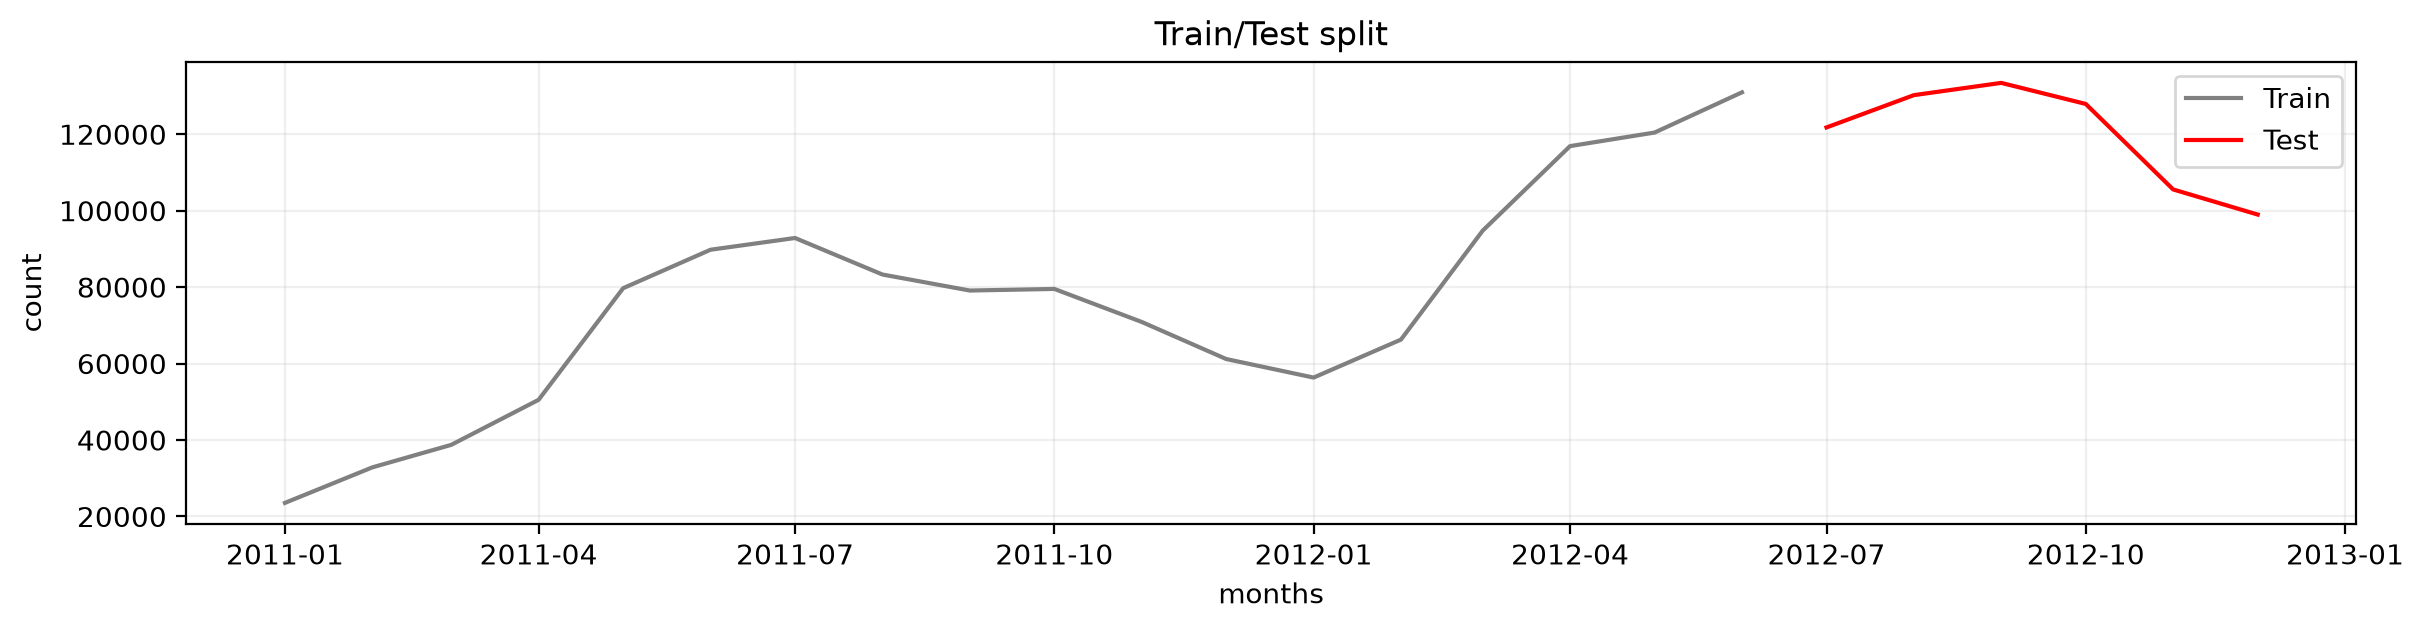

In [3]:
# TODO
# monthly 데이터를 Train / Test로 분리하세요.


use_cols = 6

monthly = monthly.sort_values(by='month')

train = monthly.iloc[:-use_cols]
test = monthly.iloc[-use_cols:]

print('[데이터 구조]')
print('Train :', train.shape)
print('Test :', test.shape)


print('\n[데이터 분리 기간]')
print(f'Train : {train.index.min()} ~ {train.index.max()}')
print(f'Test : {test.index.min()} ~ {test.index.max()}')

# Train/Test 분리 시각화
plt.figure(figsize=(14,3))

# Train
plt.plot(
    train.index,
    train['count'],
    color='gray',
    label='Train'
)

# Test
plt.plot(
    test.index,
    test['count'],
    color='red',
    label='Test'
)

plt.xlabel('months')
plt.ylabel('count')
plt.title('Train/Test split')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

- 예측 시점은 2012년 6월까지 알고 있는 상태로 가정
- 2012년 12월까지의 데이터가 존재하더라도 시계열에서 예측 시점에는 7월~12월 데이터를 모르는 것처럼 남겨둔다.
- 18개월은 18개의 관측값일 뿐 18개월치의 시간별 표본을 의미하지는 않음

> **해석** :   
> 월별 관측 합계 (총 기간) 24개월 중 앞서 18개월을 train, 마지막 6개월을 test로 분리   
> -> 2011년 1월 ~ 2012년 6월까지의 정보를 토대로 2012년 7월부터 2012년 12월까지 예측하겠다.

---

### Q1. 시계열 데이터에서 무작위로 Train / Test를 분리하면 안 되는 이유는 무엇인가요?

**답변:**  

- 시계열 데이터는 시간의 흐름(순서)을 가지는 데이터이기 때문에
- 데이터를 무작위로 분리하면 시간의 흐름이 이어지지 않게 되고,
- 미래 시점 값이 Train에 포함될 수 있다.

---

# 필수 2. ARIMA 모델 학습과 미래 값 예측

## 배경

ARIMA는 다음 세 가지 요소로 구성됩니다.

- **AR(p)**: 과거의 실제 값을 몇 개 사용할 것인가?
- **I(d)**: 차분을 몇 번 적용할 것인가?
- **MA(q)**: 과거의 예측 오차를 몇 개 사용할 것인가?

이번 실습에서는 교안과 동일하게 `ARIMA(2, 1, 1)`을 사용합니다.

## 문제 1. ARIMA(2, 1, 1)의 의미를 설명하세요.

### 요구사항

다음 세 값을 각각 설명합니다.

- `p = 2`
- `d = 1`
- `q = 1`

### Q2. 각각 무엇을 의미하나요?

**답변:**  
여기에 작성하세요.

## 문제 2. Train 데이터로 ARIMA 모델을 학습하세요.

### 요구사항

1. `statsmodels.tsa.arima.model`에서 `ARIMA`를 불러옵니다.
2. Train 데이터의 `count`를 사용합니다.
3. `order=(2, 1, 1)`을 지정합니다.
4. `fit()`으로 모델을 학습합니다.

### 확인 포인트

- Test 데이터를 학습에 사용하지 않았는가?
- `order=(p, d, q)`의 순서를 알고 있는가?

In [4]:
# TODO
# ARIMA(2, 1, 1) 모델을 생성하고 학습하세요.

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['count'], order=(2, 1, 1))
arima_model = arima_model.fit()

arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  count   No. Observations:                   18
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -180.476
Date:                Sun, 04 Oct 2026   AIC                            368.953
Time:                        16:23:11   BIC                            372.285
Sample:                    01-01-2011   HQIC                           369.284
                         - 06-01-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5770      0.932      0.619      0.536      -1.249       2.403
ar.L2         -0.1038      0.541     -0.192      0.848      -1.165       0.957
ma.L1          0.2235      1.001      0.223      0.823      -1.738       2.185
sigma2      8.347e+07   6.43e-09    1.3e+16      0.000    8.35e+07    8.35e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.81
Prob(Q):                              0.95   Prob(JB):                         0.67
Heteroskedasticity (H):               1.07   Skew:                             0.41
Prob(H) (two-sided):                  0.94   Kurtosis:                         2.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.44e+31. Standard errors may be unstable.
"""

> 상단 기본 정보

- `Dep.Variable` -> count : 학습 대상으로 사용한 월별 관측 대여량 합계
- `No. Observations` -> 18 : 입력한 Train의 관측값 개수
- `Model` -> ARIMA(2, 1, 1) : 지정한 p,d,q의 구조
- `Sample` ->	01-01-2011 ~ 06-01-2012 : 학습에 사용한 기간 범위
- `Log Likelihood` -> -180.476 : 추정한 모형이 관측자료를 설명하는 우도를 로그로 요약한 값
- `AIC` / `BIC` / `HQIC` -> 368, 372, 369 : 적합도와 모형 복작도를 함께 고려하는 정도

<br>

> 중간 모델 정보

-  `ar.L1` -> 0.577 : 직전 시점의 차분값에 적용되는 자기회귀 가중치
-  `ar.L2` -> -0.103 : 두 시점 전 차분값에 적용되는 자기회귀 가중치
-  `ma.L1` -> 0.223 : 직전 시점의 오차 및 충격에 적용되는 가중치
- `sigma2` -> 약 8.347 * 10의 7제곱 : 모형에서 추정한 오차의 분산

<br>

> 하단 모델 정보

- `coef` -> 추정계수 : 모형에 들어가는 가중치나 분산 추정값
- `std error` -> 추정 표준오차 : 계수  추정 불확실성에 관한 값
- `z` -> 계수, 표준 오차에 의한 검정통계량 : 적절한 추론 조건에서 계수가 0이라는 가설을 판단하는 데 사용
- `P` > -> z : [0.025, 0.975] : 계수 명목상 95%의 신뢰구간
- `r.L1`	    0.5770	0.932	0.619	0.536	-1.249	2.403
    - 표에서 ar.L1을 해석하는 방법 : 계수는 0.57, 표준오차는 0.93, z는 0.61, p-value는 0.53, 95% 신뢰구간 -1.2~2.4
    - 해석 : 추정 계수가 양수인 것으로 확인되지만, 표준오차가 계수보다 큰 경우, 신뢰구간도 음수에서부터 양수로 비교적 넓게 분포되어있음
    - 따라서 직전 변화량의 양의 가중치가 추정되어 있음
    - 이 데이터 예측하기 어려움
- `Ljung-Box (L1)` / `Prob(Q)`
    - 약 0.00 / 0.95 -> 표시된 1시차의 잔차 자기상관에 대한 진단
    - 0.95는 0.05보다 크기 때문에 귀무가설을 기각하지 못함
    - 귀무가설은 검사한 시차까지 잔차의 자기상관이 없다 -> 이를 기각하지 못함

- `Jarque-Bera` / `Proc(JB)`
    - 0.81 / 0.67 -> 잔차의 정규성에 대한 진단
    - 0.67은 0.05보다 크기 때문에 귀무가설을 기각하지 못함
    - 귀무가설은 잔차가 정규분포를 따른다 -> 이를 기각하지 못함 

- `Heteroskedasticity` / `Prob(H)`
    - 1.07 / 0.94 -> 오차의 크기가 시간에 따라 달라지는지
    - 초반에는 오차가 +-10정도 후반에는 +-100정도로 시간이 지남에 따라 오차의 불확실성이 커진다

- `Skew`
    - 0.41
    - 왜도 : 오차의 분포가 어느 방향으로 대칭 또는 비대칭을 이루고 있나요?
    - 0에 가까울 수록 좌우 대칭 모양
    - 지금은 0.41로 양의 대칭을 보이는, 즉 양수방향으로 꼬리가 긴 분포

- `Kurtosis`
    - 2.30
    - 첨도 : 3을 기준으로 정규분포에서 얼마나 극단적인 값들이 분포가 되어있을까?

- `ARIMA`
    - 자기회귀차수(`p`) : 과거 시차의 범위를 정하는 값
        - -> 월별 ARIMA(2,0,0)이면 7월을 설명할때 6월과 5월 매출을 사용하겠다는 의미

    - 차분 차수(`d`) : ARIMA에서 차분을 몇 번 적용할지 나타내는 값
        - -> d = 0(차분 x), d = 1(1차 차분), d = 2(2차 차분)

    - 이동 평균 차수(`q`) : 과겨 충격의 시차 범위를 정하는 값
        - -> 월별 q=2라면 7월을 설명할 때 6월과 5월의 추정 오차를 반영하겠다.

---

### Q2. 각각 무엇을 의미하나요?

- `p = 2`
- `d = 1`
- `q = 1`


**답변:**  

- `p = 2` : 1차 차분한 시계열의 이전 2개의 과거 시점의 데이터를 사용한다.
- `d = 1` : 1번 차분을 적용한다.
- `q = 1` : 현재 분석 시점에서 이전 1개의 과거 시점의 추정 오차를 반영한다.

## 문제 3. Test 기간만큼 미래 값을 예측하세요.

### 요구사항

1. `forecast()`를 사용합니다.
2. `steps=len(test)`로 Test 기간과 같은 개수만큼 예측합니다.
3. 예측값의 인덱스를 Test 데이터의 인덱스와 동일하게 설정합니다.
4. `actual`, `predicted` 컬럼을 가진 DataFrame을 만듭니다.
5. 실제값과 예측값을 같은 그래프에 표시합니다.

### 확인 포인트

- Train 마지막 시점 이후의 값을 예측했는가?
- Test 길이와 예측값 개수가 같은가?
- Actual과 Predicted를 구분했는가?

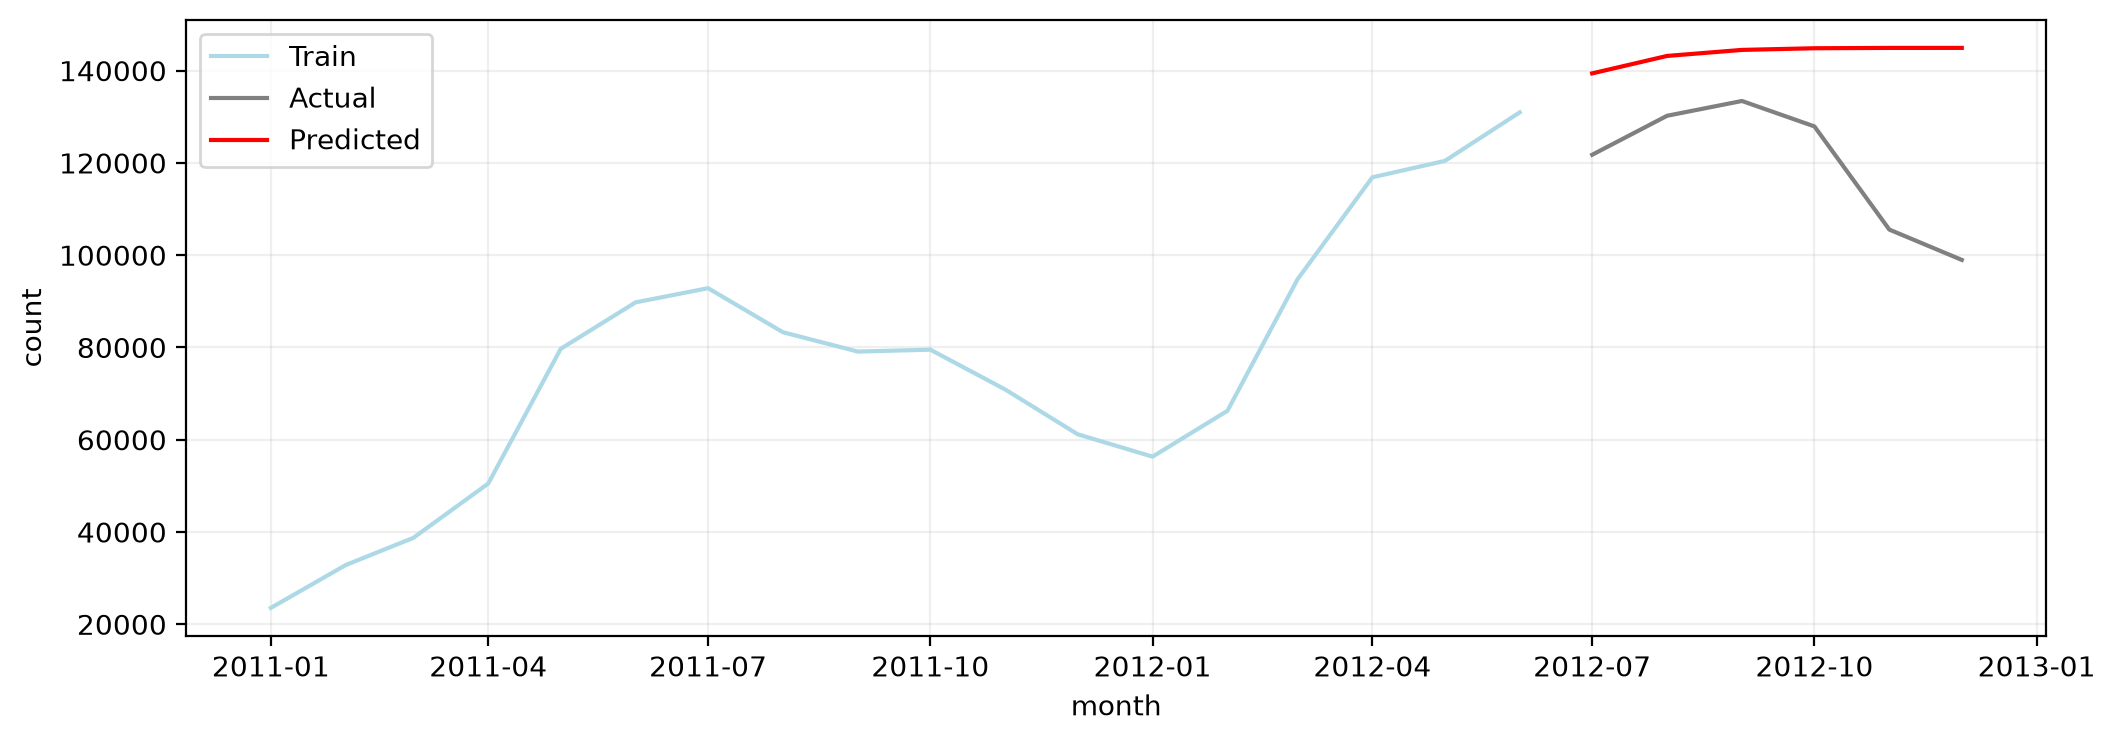

test 데이터 수 : 6
test 예측 데이터 수 : 6


,month,Actual,Predict,Gap
0,2012-07-01,121769,139405.881,17636.881
1,2012-08-01,130220,143188.735,12968.735
2,2012-09-01,133425,144494.521,11069.521
3,2012-10-01,127912,144855.327,16943.327
4,2012-11-01,105551,144927.980,39376.980
5,2012-12-01,98977,144932.452,45955.452


In [5]:
# TODO
# Test 기간만큼 예측하고 Actual / Predicted를 비교하세요.

forecast_result = arima_model.get_forecast(steps=len(test))

forecast = forecast_result.predicted_mean
forecast.index = test.index

result_df = pd.DataFrame({
    'Actual' : test['count'],
    'Predict' : forecast,
    'Gap' : forecast - test['count']
}).round(3)


# 시각화
plt.figure(figsize=(12, 4))

# Train data
plt.plot(
    train.index,
    train['count'],
    color='lightblue',
    label='Train'
)

# Actual Graph
plt.plot(result_df.index, result_df['Actual'],
         color = 'gray',
         label = 'Actual')

# Predicted Graph
plt.plot(result_df.index, result_df['Predict'],
         color = 'red',
         label = 'Predicted')


plt.xlabel('month')
plt.ylabel('count')
plt.grid(alpha=0.2)
plt.legend()

plt.show()

print(f'test 데이터 수 : {test.shape[0]}')
print(f'test 예측 데이터 수 : {forecast.shape[0]}')

display(result_df.reset_index())


- 2012-07 : 실제 관측 합계 121,769 / 예측합계 139,405 -> 약 17,636건 과대예측
- 2012-08 : 실제 관측 합계 130,220 / 예측합계 143,188.735 -> 약 12968.735건 과대예측
- 2012-09 : 실제 관측 합계 133,425 / 예측합계 144494.521 -> 약 11069.521건 과대예측
    - -> 과대예측하는 경향이 보임
> 해석 :    
> 2011년 1월~2012년 6월까지 18개월을 학습하여 향후 6개월을 예측했다.   
> 예측값은 모든 Test월에서 실제보가 높게 측정되었으며 오차가 큰 편이였다.    
> 정확하게 해석하기 위해서 추가적인 성능평가도 함께 확인해야한다.

---

### Q3. `steps=len(test)`는 무엇을 의미하나요?

**답변:**  
- Test 데이터와 동일한 개수의 미래시점을 예측한다는 의미
- 이번 모델링에서는 향후 6개월임


### Q4. Actual과 Predicted는 각각 무엇을 의미하나요?

**답변:**  

- Actual : Test 기간에 실제로 관측된 자전거 대여량
- Predicted : Train 데이터만 학습한 ARIMA 모델이 주어진 Test 기간에 대해 예측한 값

---

# 과제 1. 정상성 진단을 반영한 ARIMA 예측과 예측 신뢰도 평가

## 배경

필수 1의 Train/Test 분리는 유지합니다. 과제에서는 Train 데이터의 정상성을 먼저 진단한 뒤 ARIMA의 차분 차수 d를 선택하여 모델을 다시 학습합니다. MAE·RMSE와 함께 **95% 예측 구간의 하한·상한**을 실제값과 비교합니다.

## 요구사항

1. 필수 1에서 만든 `train`, `test`를 사용합니다. 정상성 진단과 모델 설정에는 Train만 사용합니다.
2. Train의 `count`와 최근 3개 관측값의 이동평균을 그래프로 확인합니다. 원본에 ADF Test를 수행하고 검정통계량과 p-value를 출력합니다. 짧은 월별 자료이므로 이번 과제의 검정 설정은 `maxlag=1, regression="c", autolag="AIC"`로 통일합니다.
3. 유의수준 0.05에서 원본의 단위근 귀무가설을 기각하면 d=0을 우선 검토합니다. 기각하지 못하면 1차 차분한 Train에 같은 설정으로 ADF Test를 다시 수행하고 차분 그래프를 확인합니다. 차분 후 기각하면 d=1을 선택합니다. 차분 후에도 기각하지 못하면 추가 진단이 필요함을 명시하고, 이번 과제에서는 d=1을 잠정 설정하여 예측 과정과 한계를 함께 평가합니다. 선택 근거에 그래프 해석도 포함합니다.
4. **차분하지 않은 Train의 원본 `count`**를 `ARIMA(order=(2, d, 1))`에 전달해 학습합니다. 차분은 모델 내부에서 처리하므로 차분 데이터에 d=1을 다시 적용하지 않습니다. 필수 2의 모델·결과와 구분하여 과제용 변수를 사용합니다.
5. `get_forecast(steps=len(test))`로 Test 기간의 예측값과 95% 예측 구간을 구합니다. `predicted_mean`과 `conf_int(alpha=0.05)`를 활용합니다.
6. Test 날짜에 맞춰 `actual`, `predicted`, `lower_95`, `upper_95`를 가진 `task_result`를 만들고 출력합니다.
7. 과제 모델의 MAE·RMSE를 계산하고 의미를 설명합니다.
8. 실제값·예측값·95% 예측 구간을 같은 그래프에 표시합니다. 시점별 구간 폭과 실제값의 구간 포함 여부를 표에 추가하고, 구간 밖인 시점을 확인합니다.
9. 실제값과 구간의 비교 및 구간 폭을 근거로 예측 신뢰도를 해석합니다. 신뢰도가 낮다고 판단한 구간의 가능한 원인 또는 모델의 한계를 한 가지 이상 설명합니다. 구간 밖인 시점이 없더라도 구간 폭과 자료의 한계를 검토합니다.

> Test는 최종 평가에만 사용합니다. Test 결과를 보고 d나 다른 모델 설정을 다시 선택하지 않습니다. 월별 값은 제공된 CSV의 관측값 합계이며, 월 전체 날짜가 없으면 완전한 월간 총수요로 해석하지 않습니다.

### 확인 포인트

- Train만으로 정상성을 진단하고 d 선택 근거를 제시했는가?
- 1차 차분 후에도 귀무가설을 기각하지 못한 경우 잠정 모델의 한계를 밝혔는가?
- 원본 Train을 모델에 입력하여 이중 차분을 피했는가?
- MAE·RMSE와 실제값·예측값·예측 구간을 함께 확인했는가?
- 구간 밖 실제값과 구간 폭을 근거로 예측 신뢰도와 한계를 설명했는가?
- Q5~Q9에 모두 답했는가?


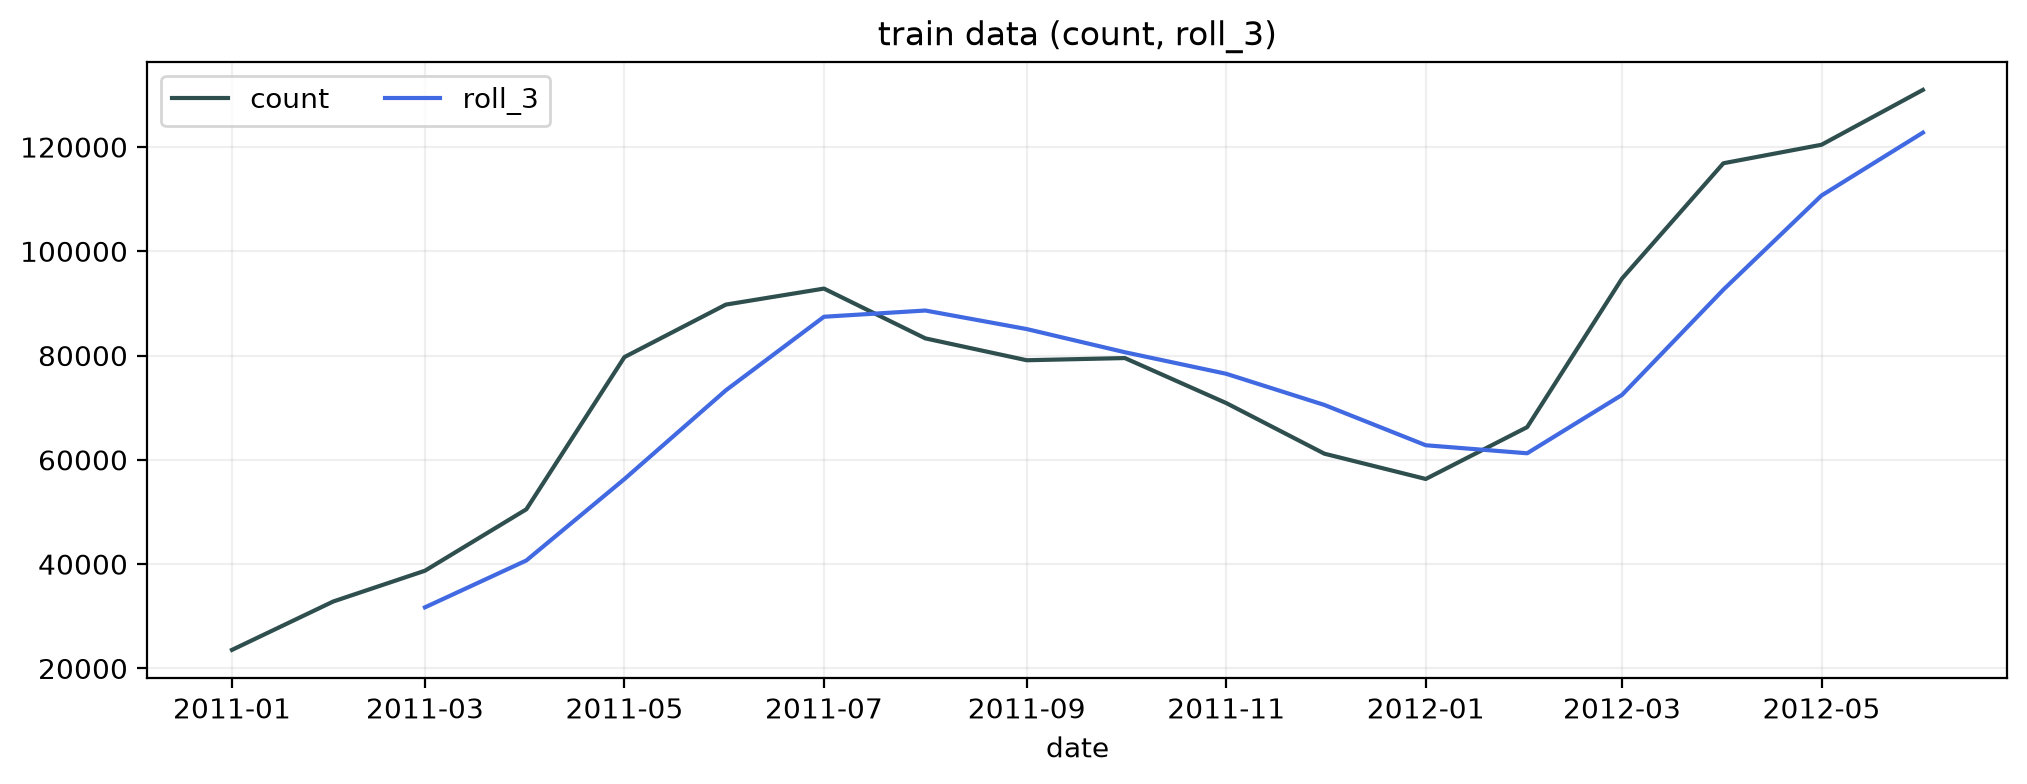

[원본 ADF 검정]
원본 ADF 검정통계량: -1.5711
원본 ADF p-value: 0.4981
원본: 단위근 귀무가설 기각 실패 | 1차 차분 후 재검정 필요

[1차 차분]


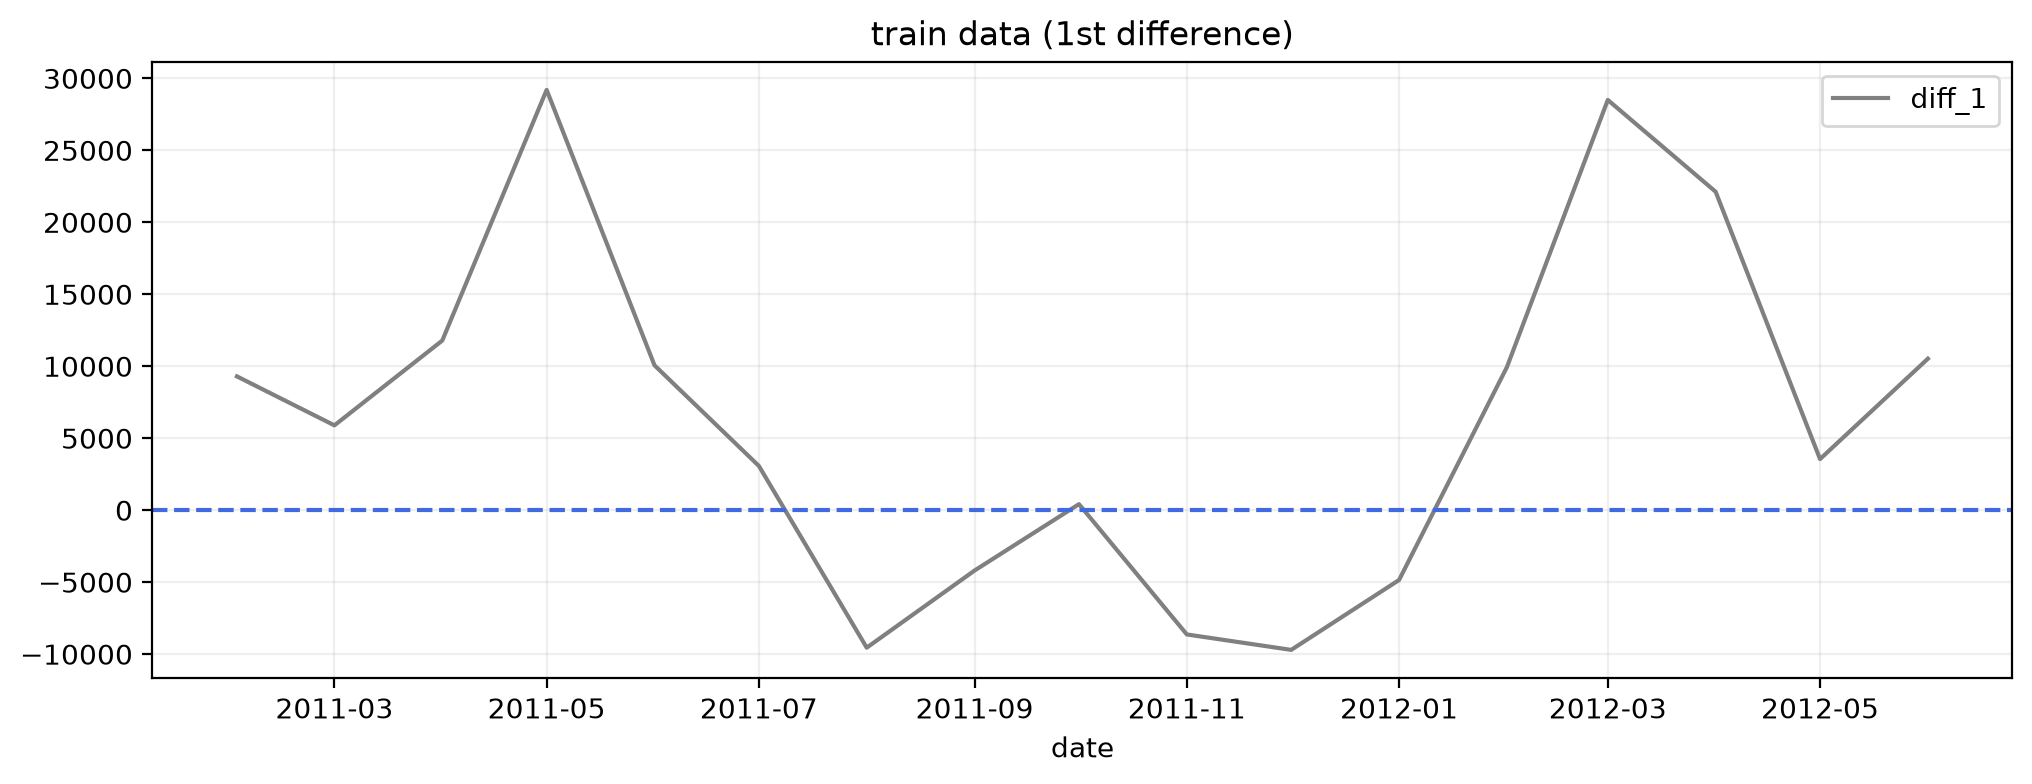

[1차 차분 후 ADF 검정]
차분 후 ADF 검정통계량: -1.9814
차분 후 ADF p-value: 0.2948
1차 차분: 단위근 귀무가설 기각 실패 | 추가검정 필요
d=1 잠정 설정

[예측 결과표]


,date,actual,predicted,lower_95,upper_95
2012-07-01,2012-07-01,121769,139405.880747,121498.779333,157312.982161
2012-08-01,2012-08-01,130220,143188.734869,106308.088275,180069.381463
2012-09-01,2012-09-01,133425,144494.520962,91068.735675,197920.306250
2012-10-01,2012-10-01,127912,144855.327198,77591.955698,212118.698697
2012-11-01,2012-11-01,105551,144927.980321,65904.510087,223951.450556
2012-12-01,2012-12-01,98977,144932.451506,55628.120842,234236.782170


MAE: 23991.8159
RMSE: 27541.8118

[예측 구간 밖의 시점]


,date,actual,predicted,lower_95,upper_95,interval_width,within_95


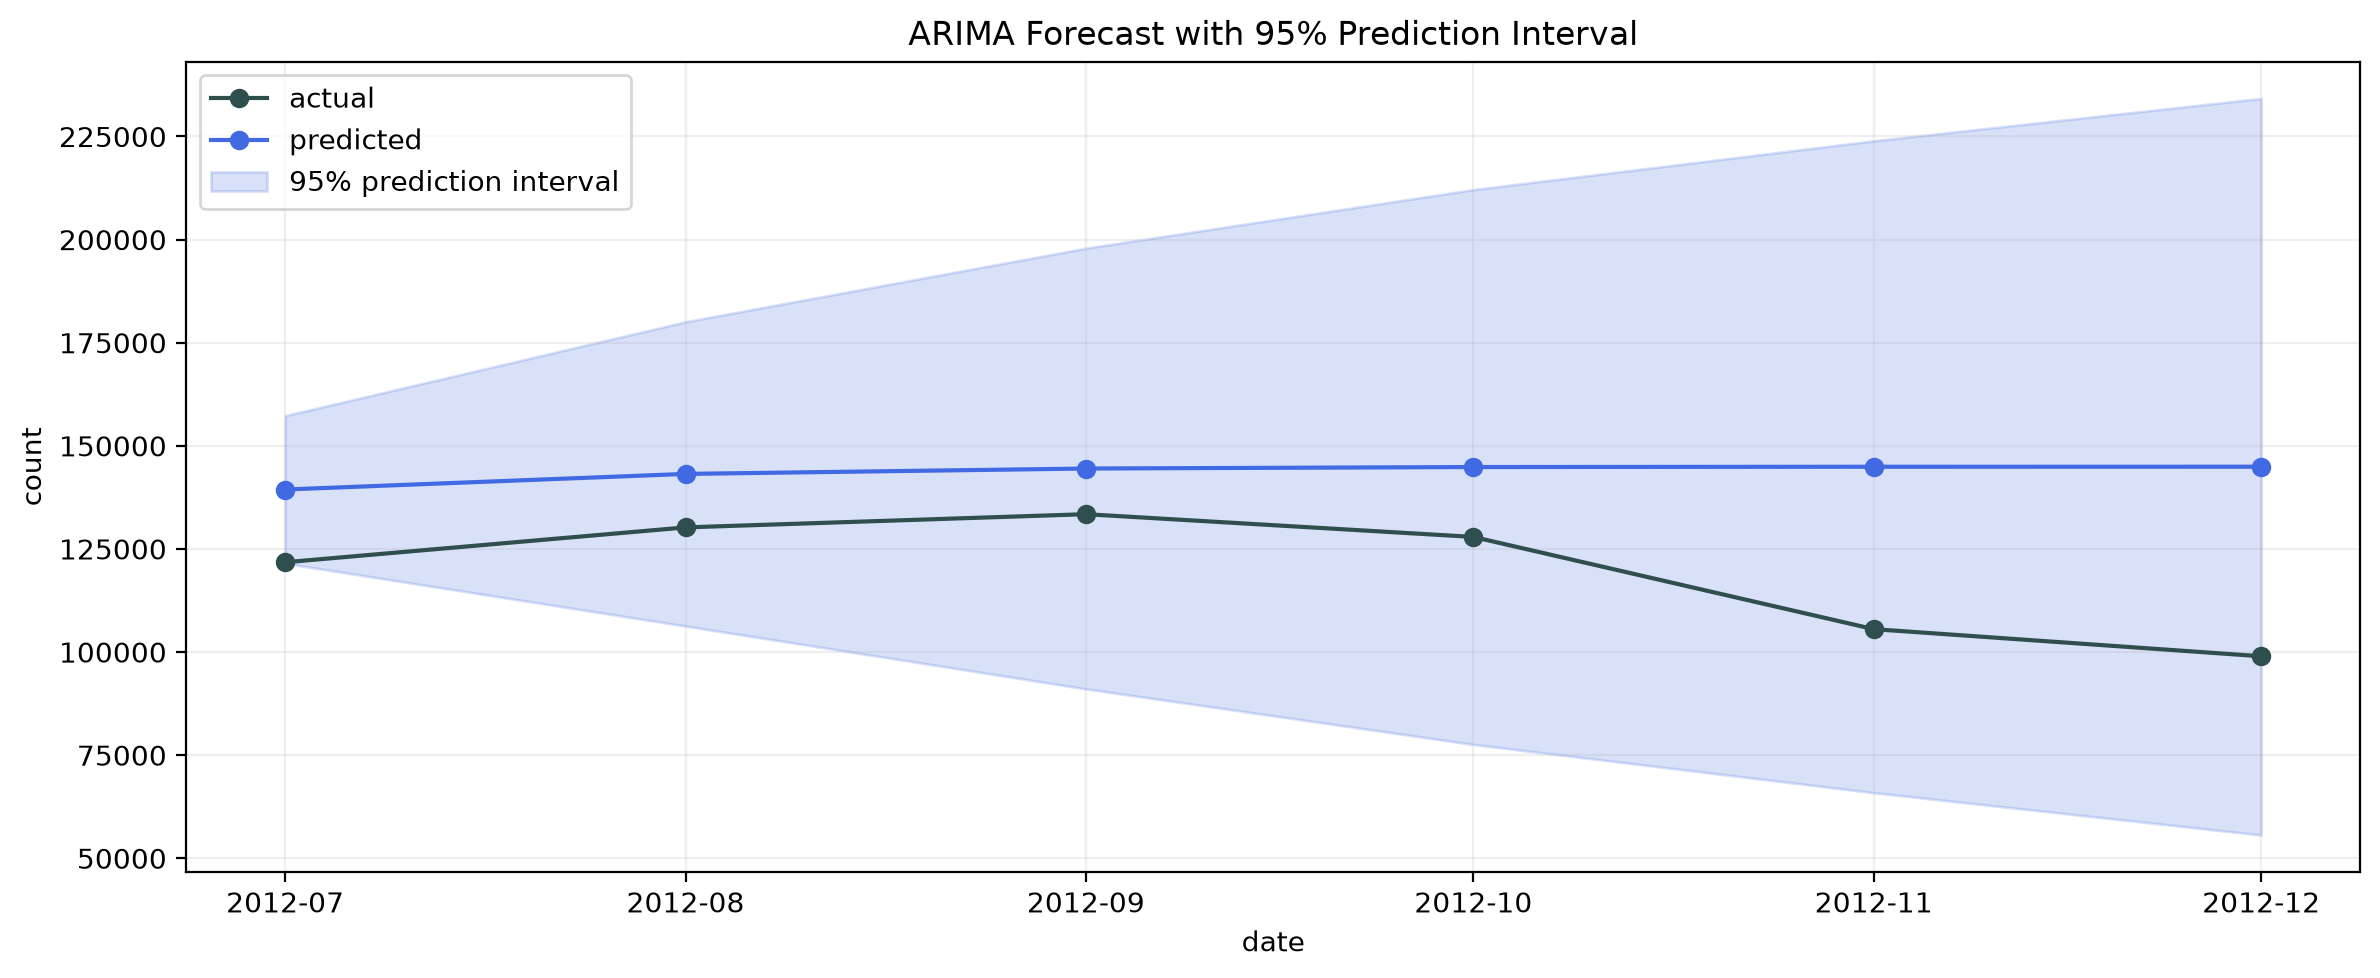

In [6]:
# TODO
# Train 정상성 진단 → d 선택 → 과제용 ARIMA 학습
# → 점예측·95% 예측 구간 → MAE·RMSE → 신뢰도 및 한계 해석

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

#============================================
# 2. 이동평균(window=3), ADF(statis, p-value)
#============================================

train["roll_3"] = train["count"].rolling(window=3).mean()

plt.figure(figsize=(12, 4))
plt.plot(train.index, train["count"], color="darkslategray", label="count")
plt.plot(train.index, train["roll_3"], color="royalblue", label="roll_3")

plt.xlabel("date")
plt.grid(alpha=0.2)
plt.legend(ncol=2)

plt.title("train data (count, roll_3)")
plt.show()

# ADF 검정
raw_statis, raw_pvalue, *__ = adfuller(train["count"], maxlag=1, regression="c", autolag="AIC", result_object=False)

print("[원본 ADF 검정]")
print(f"원본 ADF 검정통계량: {raw_statis:.4f}")
print(f"원본 ADF p-value: {raw_pvalue:.4f}")

#============================================
# 3. 단위근 귀무가설 검토, 차분 그래프 확인
#============================================
if raw_pvalue < 0.05:
    print("원본: 단위근 귀무가설 기각")
    print("d=0 선택")
    d=0

else:
    print("원본: 단위근 귀무가설 기각 실패 | 1차 차분 후 재검정 필요")

    print("\n[1차 차분]")

    train_diff = train["count"].diff().dropna() # 1차 차분

    plt.figure(figsize=(12, 4))
    plt.plot(train_diff, color="gray", label="diff_1")
    
    plt.axhline(0, color="royalblue", linestyle="--")
    plt.xlabel("date")
    plt.title("train data (1st difference)")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

    diff_statis, diff_pvalue, *__ = adfuller(train_diff, maxlag=1,regression="c",autolag="AIC",result_object=False)

    print("[1차 차분 후 ADF 검정]")
    print(f"차분 후 ADF 검정통계량: {diff_statis:.4f}")
    print(f"차분 후 ADF p-value: {diff_pvalue:.4f}")

    if diff_pvalue < 0.05:
        print("1차 차분: 단위근 귀무가설 기각")
        print("d=1 선택")
        d=1

    else:
        print("1차 차분: 단위근 귀무가설 기각 실패 | 추가검정 필요")
        print("d=1 잠정 설정")
        d=1 # 잠정 설정


#============================================
# 4. ARIMA 모델 학습
#============================================
arima_model = ARIMA(train["count"], order=(2, d, 1)).fit()


#============================================
# 5. 예측, 95% 예측구간 
#============================================
arima_forecast = arima_model.get_forecast(steps=len(test))

pred = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int(alpha=0.05)


#============================================
# 6. 예측 결과표 작성
#============================================
task_result = pd.DataFrame({
        "date" : test.index,
        "actual" : test["count"],
        "predicted" : pred,
        "lower_95" : arima_ci.iloc[:, 0],
        "upper_95" : arima_ci.iloc[:, 1]
})

print("\n[예측 결과표]")
display(task_result)


#============================================
# 7. MAE, RMSE
#============================================
mae = mean_absolute_error(task_result["actual"], task_result["predicted"])
rmse = root_mean_squared_error(task_result["actual"], task_result["predicted"])

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



#============================================
# 8. 예측 구간 폭과 실제값 포함 여부
#============================================
task_result["interval_width"] = task_result["upper_95"] - task_result["lower_95"]

task_result["within_95"] = (
    (task_result["actual"] >= task_result["lower_95"]) &
    (task_result["actual"] <= task_result["upper_95"])
)

# 예측 구간 밖의 시점
task_outside = task_result[~task_result["within_95"]]

print("\n[예측 구간 밖의 시점]")
display(task_outside)


# 9. 예측 결과 시각화
plt.figure(figsize=(12, 5))

plt.plot(
    task_result.index,
    task_result["actual"],
    color="darkslategray",
    marker="o",
    label="actual"
)

plt.plot(
    task_result.index,
    task_result["predicted"],
    color="royalblue",
    marker="o",
    label="predicted"
)

plt.fill_between(
    task_result.index,
    task_result["lower_95"],
    task_result["upper_95"],
    color="royalblue",
    alpha=0.2,
    label="95% prediction interval"
)

plt.xlabel("date")
plt.ylabel("count")
plt.title("ARIMA Forecast with 95% Prediction Interval")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

### Q5. MAE는 어떻게 해석할 수 있나요?

**답변:**
- MAE는 23,991.82로, 월별 실제 대여량과 예측값 사이에 평균 약 23,992건의 오차가 발생했다는 것을 의미한다.

### Q6. RMSE가 MAE보다 큰 오차에 더 민감한 이유는 무엇인가요?

**답변:**
- RMSE는 오차를 제곱하여 계산하기때문에 큰 오차에 더 민감하다.

### Q7. Train 데이터의 ADF 검정 결과와 그래프를 근거로 d를 어떻게 선택했나요? 정상성 판단에 남아 있는 한계는 무엇인가요?

**답변:**
- 원본(p=0.4981)과 1차 차분(p=0.2948)후 ADF 검정의 p-value는 모두 0.05보다 커 단위근 귀무가설을 기각하지 못하였다.

- 또한 그래프 상에서도 장기적인 패턴이 나타나지 않아 보였다.

- 따라서 정상성이 확인되지 않았지만 과제 조건에 따라 `d=1`을 잠정 설정하였으며, 추가적인 정상성 진단이 필요하다.

### Q8. Test 실제값이 95% 예측 구간 밖에 나타난 시점은 언제이며, 구간 폭은 시점별로 어떻게 달라지나요? 이를 근거로 예측 신뢰도를 설명하세요.

**답변:**
- 모든 Test 데이터의 실제값이 95% 예측 구간에 포함되어 구간 밖의 시점은 나타나지 않았다.

- 하지만 95% 예측 구간의 구간 폭이 미래 시점으로 갈수록 예측 불확실성이 커지는 것을 보였다.

### Q9. 예측 신뢰도가 낮다고 판단한 시점 또는 구간은 어디인가요? 가능한 원인이나 모델의 한계를 한 가지 이상 설명하세요.

**답변:**
- 11월과 12월은 예측오차가 각각 약 39,377건과 45,955건으로 크고 예측 구간도 넓어 예측의 정밀도가 낮다고 판단될 수 있다.

- 이는 ARIMA 모델이 계절적 특성 또는 변화의 추세를 충분히 반영하지 못했을 가능성이 있다.

- 따라서 표본 증가 또는 추가적인 차분, 검정이 필요하여 보인다. 


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 Train/Test 분리에서 가장 중요한 원칙은 무엇인가요?
    - 시간 순서를 유지한다는 원칙
2. ARIMA의 `p`, `d`, `q`는 각각 무엇을 의미하나요?
    - `p` : 차분 후 시계열의 과거값 개수
    - `d` : 차분 횟수
    - `q` : 사용할 과거예측의 오차의 개수

3. `forecast(steps=6)`은 무엇을 의미하나요?
    - Train의 마지막 시점 이후 6개의 미래 시점을 예측

4. Actual과 Predicted의 차이는 무엇인가요?
    - 실제 Test 값과 모델이 예측한 Predicted의 값

5. MAE와 RMSE는 값이 클수록 좋은 지표인가요, 작을수록 좋은 지표인가요?
    - 두 지표 모두 작을 수록 실제값과 예측값의 차이가 작다.